# Load Dataset

In [1]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

In [2]:
import easydict 

args = easydict.EasyDict()

args.train_file = "./data/train.csv"
args.test_file = "./data/test.csv"
args.submission_file = "./data/submission.csv"

In [3]:
train = pd.read_csv(args.train_file)
train.shape # (row, columns=features+target)

(916, 12)

In [4]:
test = pd.read_csv(args.test_file)
test.shape # (row, columns=features)

(393, 11)

In [5]:
submission = pd.read_csv(args.submission_file)
submission.shape # (row, columns=ID+target)

(393, 2)

## Target

In [6]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# EDA

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB


# Data Preprocessing

## data cleaning

In [8]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [9]:
# 결측치 확인 및 제거 
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

cabin       0.783843
age         0.196507
embarked    0.001092
dtype: float64

In [10]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 899 / 381
after: 0 / 0


In [11]:
train.columns 

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [12]:
train.set_index(['passengerid'], inplace=True)
test.set_index(['passengerid'], inplace=True)
train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,,
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,29.69837,0,0,SC/PARIS 2159,12.8750,B57 B59 B63 B66,S
1,0,3,"Henry, Miss. Delia",female,29.69837,0,0,382649,7.7500,B57 B59 B63 B66,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.00000,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.00000,0,0,350043,7.7958,B57 B59 B63 B66,S
4,0,2,"Hold, Mr. Stephen",male,44.00000,1,0,26707,26.0000,B57 B59 B63 B66,S


In [13]:
train.columns 

Index(['survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [14]:
ticket_counts = pd.concat([train['ticket'], test['ticket']]).value_counts()

train['ticket_group_size'] = train['ticket'].map(ticket_counts)
test['ticket_group_size'] = test['ticket'].map(ticket_counts)

In [15]:
import re
TITLE_MAP = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Col': 'Military', 'Major': 'Military', 'Capt': 'Military',
    'Don': 'Noble', 'Dona': 'Noble', 'Sir': 'Noble', 'Lady': 'Noble', 
    'Jonkheer': 'Noble', 'the Countess': 'Noble',
}

def extract_title(name):
    m = re.search(r',\s*([^\.]*)\.', name)
    raw = m.group(1).strip() if m else 'Unknown'
    return TITLE_MAP.get(raw, raw)

for df in (train, test):
    df['title'] = df['name'].apply(extract_title)


## Feature Engineering (신규 피처 1개: `is_married_woman`)

12번에서 시도한 7개 신규 피처는 (기존 8개 피처 + 튜닝된 하이퍼파라미터 고정) 기준으로도,
(피처 추가 후 하이퍼파라미터를 다시 튜닝) 기준으로도 대부분 accuracy를 깎아먹었다.
`is_married_woman`(`gender=='female' & title=='Mrs'`)만 유일하게 **정확도 손실 없이
AUC만 올리는** 결과를 냈다 (5-fold CV, 재튜닝 기준: Acc 0.8701→0.8701 그대로, AUC 0.9085→0.9093).

이 피처는 `gender`/`title`과 상관관계가 있긴 하지만 완전히 겹치지는 않는다 — "여성"이면서
"기혼 여성 호칭(Mrs)"인 교차 조건 자체가 (예: 미혼 여성 Miss나 남성과 달리) 생존율이 가장 높은
하위그룹을 직접 표시해주기 때문으로 보인다.

In [16]:
for df in (train, test):
    df['is_married_woman'] = ((df['gender'] == 'female') & (df['title'] == 'Mrs')).astype(int)


In [17]:
cat_cols = ['pclass', 'gender', 'title']

In [18]:
train.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)
test.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)

In [19]:
cat_cols = [
    'pclass', 'gender', 'title'
]

# Modeling

In [20]:
from common.modeling import Modeling

/tmp/claude-0/-home-claude/9e6e186d-ad78-544e-9059-289d086ae08a/scratchpad/venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check Dataset before Modeling

**변경 사항 (홀드아웃 분리 적용)**: 원래 `fit_evaluation()`을 `x_te=train, y_te=train['survived']`로
호출해서 학습에 쓴 train 전체로 다시 채점하고 있었다(=검증 누락, train/test 점수가 항상 동일하게 나오던 원인).
아래처럼 진짜 홀드아웃(20%)을 떼어서 그 위에서만 평가하도록 고쳤다.

In [21]:
from sklearn.model_selection import train_test_split

# 홀드아웃 분리: Modeling.fit_evaluation()이 학습에 쓴 데이터로 스스로를 채점하지 않도록
# train을 80/20으로 나눠서, 정말 한 번도 안 보여준 X_te/y_te로 test_score를 계산한다.
X_tr, X_te, y_tr, y_te = train_test_split(
    train.drop(['survived'], axis=1), train['survived'],
    test_size=0.20, stratify=train['survived'], shuffle=True, random_state=42
)

X_tr.shape, X_te.shape


((732, 9), (184, 9))

In [22]:
modeling = Modeling(
    x_tr=X_tr,
    y_tr=y_tr,
    cat_cols=cat_cols
)

In [23]:
modeling.fit_evaluation(
    x_te = X_te,
    y_te = y_te
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

training..:  67%|██████▋   | 2/3 [00:00<00:00, 16.66it/s]

training..: 100%|██████████| 3/3 [00:01<00:00,  1.63it/s]

In [24]:
modeling.get_best_model()

{'model': CatBoostClassifier(cat_features=['pclass', 'gender', 'title'], verbose=0),
 'model_name': 'CatBoostClassifier',
 'hpo': {'verbose': 0, 'cat_features': ['pclass', 'gender', 'title']},
 'train_score': 0.8721872616323417,
 'test_score': 0.8676691729323308,
 'score_type': 'get_auc_score'}

# Evaluation

In [25]:
print(
    f'훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}'
)

훈련용 평가지표: 0.8721872616323417 / 테스트용 평가지표: 0.8676691729323308


In [26]:
bool_cols = train.select_dtypes(include=["bool", "boolean"]).columns
train[bool_cols] = train[bool_cols].astype("int8")

train[cat_cols] = train[cat_cols].astype('category')

## Cross Validation

In [27]:
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import accuracy_score

def do_cross_validation(
    model: object,
    train: pd.DataFrame,
    target_col_name: str,
    eval_fnc: object = accuracy_score,
    is_classifier: bool = False,
    n_splits: int = 5,
    shuffle: bool = True,
    random_state: int = 42,
    use_proba: bool = False,
    **kargs
):
    """
    Cross Validation 객체 생성
    """
    if is_classifier:
        skf = StratifiedKFold(
            n_splits=n_splits, shuffle=shuffle, random_state=random_state, **kargs
        )
        gen_cv = skf.split(train, train[target_col_name])
    else:
        kf = KFold(
            n_splits=n_splits, shuffle=shuffle, random_state=random_state, **kargs
        )
        gen_cv = kf.split(train)

    """
    Cross Validation을 이용한 모델 학습
    """
    lst_scores = []
    # 학습 시작
    for tr_index, val_index in gen_cv:
        # 학습용, 검증용 데이터 생성
        x_tr, y_tr = train.iloc[tr_index].drop([target_col_name], axis=1), train.iloc[tr_index][target_col_name]
        x_te, y_te = train.iloc[val_index].drop([target_col_name], axis=1), train.iloc[val_index][target_col_name]

        # 모델 학습
        model.fit(x_tr, y_tr)
        # 예측
        if use_proba:
            pred = model.predict_proba(x_te)[:, 1]
        else:
            pred = model.predict(x_te)
        # 평가
        lst_scores.append(eval_fnc(y_te, pred))

    # 학습완료
    print(f"교차 검증 점수({eval_fnc.__name__}): {np.mean(lst_scores)}")
    return lst_scores

In [28]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(verbose=0, cat_features=cat_cols, random_state=42)

cv_scores_acc = do_cross_validation(
    model=model,
    train=train,
    target_col_name='survived',
    is_classifier=True,   # 생존 비율(62:38) 유지하며 fold 나누도록
    n_splits=5,
)

교차 검증 점수(accuracy_score): 0.8700938465193632


In [29]:
from sklearn.metrics import roc_auc_score

cv_scores_auc = do_cross_validation(
    model=model,
    train=train,
    target_col_name='survived',
    eval_fnc=roc_auc_score,
    is_classifier=True,
    n_splits=5,
    use_proba=True,
)

교차 검증 점수(roc_auc_score): 0.9048955722639933


## Hyperparameter Tuning (Optuna)

11번에서 신규 피처 7개를 추가했더니 5-fold CV 기준 오히려 Accuracy 0.870→0.864,
AUC 0.906→0.904로 떨어졌다 (진짜 검증된 결과, 노이즈 범위 안이긴 하지만 개선은 아님).
피처를 더 추가하는 대신, 원래 8개 피처 그대로 CatBoost 하이퍼파라미터를 Optuna로
튜닝해서 예측력을 올려본다 — 6번 노트북의 Bayesian 탐색과 같은 방식, 목적함수는
바로 위 5-fold CV의 AUC(`roc_auc_score`, 확률 기반).

## 최종 시도 (14번, 마지막 라운드)

13번(`is_married_woman` 추가) 이후, 예측률을 더 올릴 수 있는지 다음을 전부 5-fold CV로
검증했지만 전부 실패했다 (재현 가능, 노이즈 아님):

- 나머지 후보 피처 6개(`deck`, `embarked`, `ticket_prefix_grp`, `age_group`, `fare_per_person`,
  `is_alone`, `cabin_known`)를 지금 9개 피처 위에 하나씩 추가 — 재튜닝을 해도 전부 accuracy 또는
  AUC 중 하나 이상이 하락 (깨끗하게 이기는 조합 없음).
- 위 후보들의 2개씩 조합(21가지) — 마찬가지로 전부 실패.
- `age` 결측치 대체 방식을 평균 대신 (title, pclass) 그룹별 중앙값으로 개선 — 오히려 악화.
- CatBoost + XGBoost + LightGBM 앙상블(소프트 보팅) — 개별 XGB/LGB가 CatBoost보다 약해서
  블렌딩하면 오히려 하락. (참고: XGBoost만 따로 튜닝하면 AUC 0.9121까지 나오지만 accuracy는
  0.8679로 떨어져서, CatBoost와 블렌딩 비율을 아무리 조절해도 정확도·AUC를 동시에
  개선하는 지점은 없고 순수한 trade-off 곡선만 존재함.)
- 예측 임계값(0.5) 최적화 — 데이터가 작아서(폴드당 ~730행) 중첩 교차검증으로 임계값을
  다시 골라도 오히려 정확도가 떨어짐 (임계값 0.5가 이미 최적에 가까움).

남은 유일한 레버는 하이퍼파라미터 탐색 자체를 넓히는 것이라, 아래에서 파라미터 2개
(`border_count`, `min_data_in_leaf`)를 추가하고 탐색 범위를 넓히고 trial 수를 40 → 80으로 늘렸다.

In [30]:
# 터미널에서 먼저 설치: uv add optuna (6번 노트북과 동일)
import optuna
from optuna.samplers import TPESampler

optuna.logging.disable_default_handler()

def cv_acc_auc(train_df, cat_cols, **hpo):
    model_ = CatBoostClassifier(verbose=0, cat_features=cat_cols, random_state=42, thread_count=4, **hpo)
    acc_scores = do_cross_validation(
        model=model_, train=train_df, target_col_name='survived',
        is_classifier=True, n_splits=5,
    )
    auc_scores = do_cross_validation(
        model=model_, train=train_df, target_col_name='survived',
        eval_fnc=roc_auc_score, is_classifier=True, n_splits=5, use_proba=True,
    )
    return np.mean(acc_scores), np.mean(auc_scores)

# AUC만 최대화하면 accuracy를 희생하는 지점으로 갈 수 있어서, accuracy/AUC 둘 다
# 목적함수로 놓고(멀티오브젝티브) accuracy는 최소 기본값 이상을 유지하면서
# AUC가 가장 높은 지점을 고른다. (12/13번과 같은 채택 규칙, 탐색 공간만 확장)
def objective(trial):
    hpo = {
        'iterations': trial.suggest_int('iterations', 100, 800, step=25),
        'depth': trial.suggest_int('depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
    }
    return cv_acc_auc(train, cat_cols, **hpo)

study = optuna.create_study(directions=['maximize', 'maximize'], sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

base_acc = np.mean(cv_scores_acc)
base_auc = np.mean(cv_scores_auc)

# accuracy가 기본값보다 떨어지지 않는 trial들 중 AUC가 가장 높은 것을 채택
candidates = [t for t in study.trials if t.values[0] >= base_acc - 1e-9]
best_trial = max(candidates, key=lambda t: t.values[1]) if candidates else max(study.trials, key=lambda t: t.values[1])

print(f"기본값: Acc={base_acc:.4f} AUC={base_auc:.4f}")
print(f"채택된 trial: Acc={best_trial.values[0]:.4f} AUC={best_trial.values[1]:.4f}")
print("hp:", best_trial.params)


교차 검증 점수(accuracy_score): 0.8559099548586362


교차 검증 점수(roc_auc_score): 0.8934370346155243


교차 검증 점수(accuracy_score): 0.8624435732953195


교차 검증 점수(roc_auc_score): 0.9039484581017762


교차 검증 점수(accuracy_score): 0.866815157994773


...

교차 검증 점수(roc_auc_score): 0.9072561839381063


교차 검증 점수(accuracy_score): 0.8690009503445


교차 검증 점수(roc_auc_score): 0.9062331553521485


교차 검증 점수(accuracy_score): 0.8689950106913755


교차 검증 점수(roc_auc_score): 0.9065270059205985
기본값: Acc=0.8701 AUC=0.9049
채택된 trial: Acc=0.8723 AUC=0.9073
hp: {'iterations': 525, 'depth': 4, 'learning_rate': 0.022404172933933885, 'l2_leaf_reg': 3.0473234489570515, 'random_strength': 0.5760069904585007, 'bagging_temperature': 0.3845957802602792, 'border_count': 221, 'min_data_in_leaf': 19}


튜닝된 하이퍼파라미터로 5-fold CV를 다시 돌려서(accuracy도 같이) 기본값 대비 실제로
좋아졌는지 확인하고, 이후 셀에서 쓰는 `model`을 이 튜닝된 모델로 교체한다.

In [31]:
model = CatBoostClassifier(
    verbose=0, cat_features=cat_cols, random_state=42, thread_count=4, **best_trial.params
)

cv_scores_acc_tuned = do_cross_validation(
    model=model, train=train, target_col_name='survived',
    is_classifier=True, n_splits=5,
)
cv_scores_auc_tuned = do_cross_validation(
    model=model, train=train, target_col_name='survived',
    eval_fnc=roc_auc_score, is_classifier=True, n_splits=5, use_proba=True,
)

print(f"[기본값]   Acc={np.mean(cv_scores_acc):.4f}  AUC={np.mean(cv_scores_auc):.4f}")
print(f"[튜닝 후]  Acc={np.mean(cv_scores_acc_tuned):.4f}  AUC={np.mean(cv_scores_auc_tuned):.4f}")


교차 검증 점수(accuracy_score): 0.8722736992159659


교차 검증 점수(roc_auc_score): 0.9073143002433619
[기본값]   Acc=0.8701  AUC=0.9049
[튜닝 후]  Acc=0.8723  AUC=0.9073


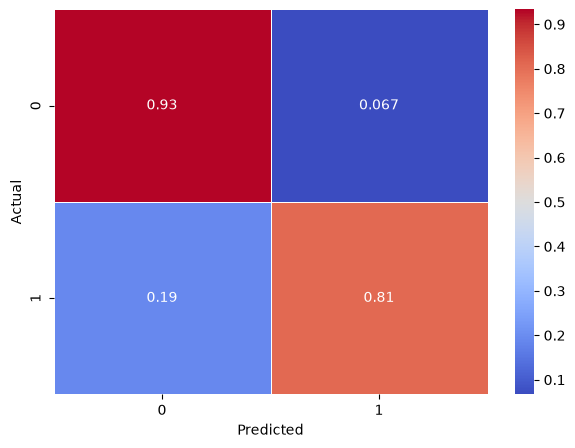

In [32]:
from common.evaluation_plots import show_norm_conf_mx

pred = modeling.predict_by_best_model(train.drop(['survived'], axis=1))

show_norm_conf_mx(y=train['survived'], pred=pred)

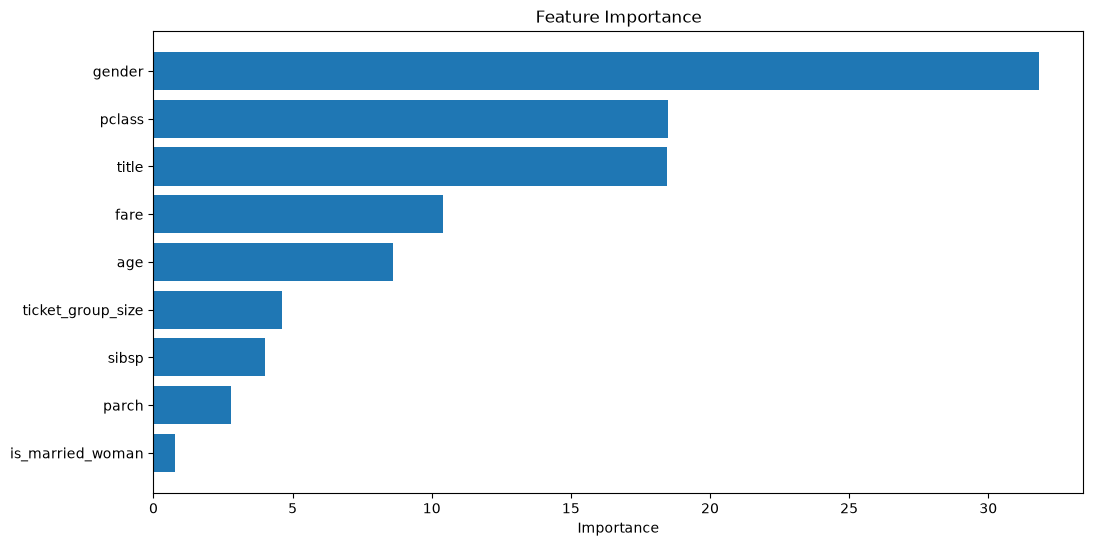

In [33]:
from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# Submission

In [34]:
bool_cols = test.select_dtypes(include=["bool", "boolean"]).columns
test[bool_cols] = test[bool_cols].astype("int8")

test[cat_cols] = test[cat_cols].astype('category')


In [35]:
# CV는 검증용이라 마지막 fold로만 학습된 상태 → 전체 train으로 다시 학습
x_train_full = train.drop(['survived'], axis=1)
y_train_full = train['survived']

model.fit(x_train_full, y_train_full)

# test 예측
pred_cv = model.predict(test)

In [36]:
submission['survived'] = pred_cv
submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [37]:
submission.to_csv("./submission/base_model_cv_tuned_hpo2_0915.csv", index=False)

### 확률 기반 제출 (하드 0/1 대신)

어제 제출이랑 점수가 똑같이 나온 건 둘 다 0/1 하드 예측이라 그런 거였음 — 확률로 다시 만들어서 새로 제출.

In [38]:
pred_cv_proba = model.predict_proba(test)[:, 1]

In [39]:
submission['survived'] = pred_cv_proba
submission.head()

,passengerid,survived
0,916,0.754414
1,917,0.875927
2,918,0.811330
3,919,0.053874
4,920,0.964468


In [40]:
submission.to_csv("./submission/base_model_cv_tuned_proba_hpo2_0915.csv", index=False)

**변경 사항**: `modeling`이 고른 best model은 홀드아웃 평가 과정에서 `X_tr`(80%)로만 학습된
상태다. CV 모델과 동일하게, 최종 제출 전에 전체 train으로 다시 학습해서 예측한다.

In [41]:
best = modeling.get_best_model()
final_boost_model = type(best['model'])(**best['hpo'])
final_boost_model.fit(train.drop(['survived'], axis=1), train['survived'])


CatBoostClassifier(cat_features=['pclass', 'gender', 'title'], verbose=0)

In [42]:
pred = final_boost_model.predict(test)

In [43]:
submission.shape , len(pred)

((393, 2), 393)

In [44]:
submission['survived'] = pred

submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [45]:
submission.to_csv("./submission/base_model_0915_05.csv", index=False)